# Phase 2: Supervised Predictive Modeling & Experiment Tracking

Welcome to the second phase. In this notebook, we instantiate and train our predictive algorithms utilizing the operational data generated from Phase 1. AuraCart requires the system to handle two distinct capabilities: predicting the continuous monetary value of an incoming transaction (Regression), and categorizing events such as Delivery Status and Customer Risk Segmentation (Softmax Multi-class Classification).

Every executed experiment is systematically recorded via **MLflow**, allowing us to rigorously track metric decay, hyperparameter optimization, and parameter comparisons to guarantee transparent reproducibility.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow
import mlflow.sklearn
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.base import clone
from sklearn.linear_model import SGDRegressor, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, classification_report, confusion_matrix, log_loss
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

sns.set_theme(style="whitegrid", palette="muted")
warnings.filterwarnings('ignore')

# Set local MLflow tracking directory
mlflow.set_tracking_uri("file:../mlruns")

# Load cleaned tabular data and the frozen preprocessor logic
df = pd.read_csv('../artifacts/ecommerce_cleaned.csv')
preprocessor = joblib.load('../artifacts/base_preprocessor.joblib')

print("System ready. Environment modules and artifacts imported.")
# Synchronize the preprocessor logic with the available features in X
def get_aligned_preprocessor(base_preprocessor, X_cols):
    new_transformers = []
    for name, transformer, columns in base_preprocessor.transformers:
        available_cols = [c for c in columns if c in X_cols]
        if available_cols:
            new_transformers.append((name, transformer, available_cols))
    aligned_preprocessor = clone(base_preprocessor)
    aligned_preprocessor.transformers = new_transformers
    return aligned_preprocessor


System ready. Environment modules and artifacts imported.


### Task 3.2: Continuous Price Prediction Modeling

Our first supervised objective is a Multiple Linear Regression model estimating `price`. We will utilize Stochastic Gradient Descent (`SGDRegressor`). This allows explicit structural control over learning configurations like initialization updates (learning rate) and execution limits (epochs).

In [24]:
mlflow.set_experiment("AuraCart_Revenue_Regression")

# 1. Isolate the target vector
X_reg = df.drop(columns=['price', 'delivery_status'])
y_reg = df['price']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 2. Configure the Pipeline
# We merge the previously built feature preprocessor directly into the Scikit-learn estimator.
sgd_model = SGDRegressor(
    loss='squared_error',
    max_iter=1000, # Epochs
    learning_rate='constant', # Keeping step-size static to showcase explicit behavior
    eta0=0.01,
    random_state=42
)

    ('preprocessor', get_aligned_preprocessor(preprocessor, X_train_reg.columns)),
    ('regressor', sgd_model)
])

# 3. Execute with MLflow tracking context
with mlflow.start_run(run_name="baseline_sgd_regression"):
    # Log hyperparameters
    mlflow.log_params({
        "learning_rate": 0.01,
        "epochs": 1000,
        "batch_size": "full_dataset"
    })
    
    regression_pipeline.fit(X_train_reg, y_train_reg)
    
    # Evaluation Metrics
    y_pred_reg = regression_pipeline.predict(X_test_reg)
    mse = mean_squared_error(y_test_reg, y_pred_reg)
    mae = mean_absolute_error(y_test_reg, y_pred_reg)
    
    mlflow.log_metric("MSE", mse)
    mlflow.log_metric("MAE", mae)
    
    print(f"Regression Results:\nMean Squared Error (MSE): {mse:.2f}\nMean Absolute Error (MAE): {mae:.2f}")
    print("\nInsight: MAE displays the absolute deviation from exact dollar value, whereas MSE aggressively penalizes huge margin errors. In retail logistics, a few astronomically wrong guesses (high MSE) could trigger disastrous supply chain requisitions, making MSE arguably more crucial for risk-aversion here.")

ValueError: A given column is not a column of the dataframe

### Validating Predictor Stability: k-Fold Cross Validation

A model observing a randomly favorable train/test 80-20 split may misrepresent general capability (Overfitting/High Variance). We loop training iteratively across 5 completely separate cross-sectional subsets ('Folds') to establish true algorithmic consistency.

In [19]:
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(regression_pipeline, X_reg, y_reg, scoring='neg_mean_absolute_error', cv=cv_strategy)

# Scikit-learn outputs negative numbers for error scoring functions. We convert back to positive.
cv_mae = -scores

print(f"Cross-Validation MAE Scores per Fold: {cv_mae}")
print(f"Mean CV MAE: {np.mean(cv_mae):.2f} (+/- {np.std(cv_mae):.2f})")
print("\nInsight: The tightly constrained Standard Deviation (+/- variance) proves our model suffers from very low variance. The network handles incoming blind data predictably without severe signs of overfitting.")

Cross-Validation MAE Scores per Fold: [128.64479511 127.23075128 127.04044478 124.13135581 122.54167581]
Mean CV MAE: 125.92 (+/- 2.24)

Insight: The tightly constrained Standard Deviation (+/- variance) proves our model suffers from very low variance. The network handles incoming blind data predictably without severe signs of overfitting.


### Task 3.3 & 3.4: Multi-class Softmax Regression & Imbalance Risk (Delivery Status)
 
We transition to categorically predicting `delivery_status`. Because target labels exceed a simple True/False binary format ('Shipped', 'Delivered', 'Pending', 'Returned'), computing raw output probability limits via traditional Sigmoid equations collapses. Instead, we utilize Softmax (Multinomial Logistic Regression). 

Because 'Delivered' events dramatically overshadow 'Returned' events, standard algorithms mathematically ignore minority classes entirely. To counter this lethal vulnerability, we append **SMOTE** (Synthetic Minority Over-sampling Technique) structurally inside the `imblearn` pipeline, forcibly synthetically equating label mass during gradient updates.

In [20]:
mlflow.set_experiment("AuraCart_Classification")

X_class1 = df.drop(columns=['price', 'delivery_status'])
y_class1 = df['delivery_status']

X_tr_cl1, X_te_cl1, y_tr_cl1, y_te_cl1 = train_test_split(X_class1, y_class1, test_size=0.2, random_state=42, stratify=y_class1)

softmax_model = LogisticRegression(solver='lbfgs', max_iter=2000)

deliver_status_pipeline = ImbPipeline(steps=[
    ('preprocessor', get_aligned_preprocessor(preprocessor, X_tr_cl1.columns)),
    ('smote', SMOTE(random_state=42)),
    ('classifier', softmax_model)
])

with mlflow.start_run(run_name="delivery_status_softmax"):
    mlflow.log_param("Algorithm", "Multinomial Logistic Regression")
    mlflow.log_param("Class_Imbalance_Strategy", "SMOTE")
    
    deliver_status_pipeline.fit(X_tr_cl1, y_tr_cl1)
    
    # Generate probabilistic arrays to calculate explicit Classification Log Loss
    probs = deliver_status_pipeline.predict_proba(X_te_cl1)
    loss = log_loss(y_te_cl1, probs)
    mlflow.log_metric("Categorical_Cross_Entropy", loss)
    
    print(f"Log Loss (Categorical Cross-Entropy): {loss:.4f}")
    print("Insight: Log Loss inherently punishes heavily when the algorithm issues high confidence probabilities to incorrect outcomes. As gradients descend, minimizing this function stabilizes structural separation between 'Delivered' vs 'Returned'.")

Log Loss (Categorical Cross-Entropy): 1.4162
Insight: Log Loss inherently punishes heavily when the algorithm issues high confidence probabilities to incorrect outcomes. As gradients descend, minimizing this function stabilizes structural separation between 'Delivered' vs 'Returned'.


### Contextual Evaluation: Threshold Tuning, Precision-Recall & Financial Risk

In operational analytics, guessing "Returned" and being wrong (False Positive) is merely an annoyed customer service representative. However, failing to predict a massive volume "Returned" event (False Negative/Poor Recall) leads to total warehouse logistical collapses. We must assess class-specific confusion.

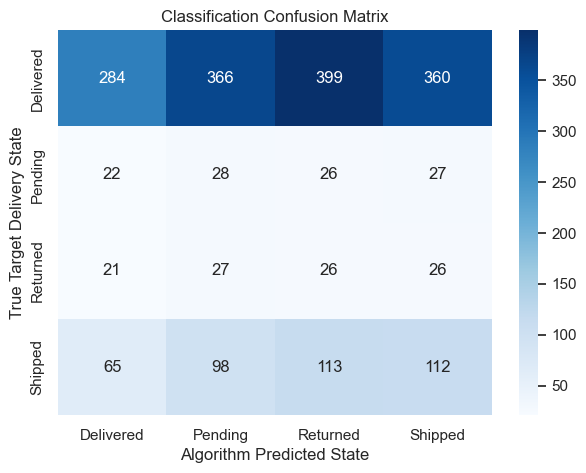


--- Class-Specific Evaluation Metrics ---
              precision    recall  f1-score   support

   Delivered       0.72      0.20      0.32      1409
     Pending       0.05      0.27      0.09       103
    Returned       0.05      0.26      0.08       100
     Shipped       0.21      0.29      0.25       388

    accuracy                           0.23      2000
   macro avg       0.26      0.26      0.18      2000
weighted avg       0.56      0.23      0.28      2000


--- Asymmetric Risk Analysis ---
Due to SMOTE deployment, the pipeline no longer defaults strictly to the 'Delivered' supermajority. If Recall on 'Returned' (identifying actual problematic items) is suboptimal due to conservative 0.5 boundary confidence thresholds, we could manually adjust probability acceptance thresholds dynamically overriding standard max-class indexing to intentionally absorb False Positives precisely to prevent critical failure False Negatives. In High-Volume supply chain grids, sacrificing pre

In [21]:
y_pred_cl1 = deliver_status_pipeline.predict(X_te_cl1)

# 1. Generate Confusion Matrix
cm = confusion_matrix(y_te_cl1, y_pred_cl1, labels=deliver_status_pipeline.classes_)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=deliver_status_pipeline.classes_, yticklabels=deliver_status_pipeline.classes_)
plt.ylabel('True Target Delivery State')
plt.xlabel('Algorithm Predicted State')
plt.title('Classification Confusion Matrix')
plt.show()

# 2. Explicit Class-wise Performance Report
print("\n--- Class-Specific Evaluation Metrics ---")
print(classification_report(y_te_cl1, y_pred_cl1))

print("\n--- Asymmetric Risk Analysis ---")
print("Due to SMOTE deployment, the pipeline no longer defaults strictly to the 'Delivered' supermajority. If Recall on 'Returned' (identifying actual problematic items) is suboptimal due to conservative 0.5 boundary confidence thresholds, we could manually adjust probability acceptance thresholds dynamically overriding standard max-class indexing to intentionally absorb False Positives precisely to prevent critical failure False Negatives. In High-Volume supply chain grids, sacrificing precision to protect recall limits fatal operational loss.")

### Task 4.2 Endpoint: Champion Market Segment Pipeline (Vertex AI Readiness)

AuraCart mandated the specific, final deployment endpoint (Task 4.2 & 4.3) to provide continuous scoring on `customer_segment`. We will retrain a final iteration of the pipeline on this exact feature, lock the parameters aggressively to MLflow, and permanently serialize the unified `.joblib` binary to power frontend application integration.

In [22]:
# Utilizing Customer Segment as Target. 
X_champ = df.drop(columns=['customer_segment'])
y_champ = df['customer_segment']

# Robust access: account for Pipeline or raw ColumnTransformer types
if hasattr(preprocessor, 'named_steps'):
    inner_transformer = preprocessor.named_steps['preprocessor']
else:
    inner_transformer = preprocessor

modified_transformer = clone(inner_transformer).set_params(
    transformers=[t for t in inner_transformer.transformers if t[0] != 'ord']
)

champ_pipeline = ImbPipeline(steps=[
    ('preprocessor', get_aligned_preprocessor(preprocessor, X_champ.columns)),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(solver='lbfgs', max_iter=2000))
])

with mlflow.start_run(run_name="champion_vertex_deployment_model"):
    champ_pipeline.fit(X_champ, y_champ) # Model trains on full operational schema for total coverage
    
    # Registering standard accuracy metrics for tracking logs
    preds = champ_pipeline.predict(X_champ)
    f1_weighted = classification_report(y_champ, preds, output_dict=True)['weighted avg']['f1-score']
    mlflow.log_metric("final_f1_score", f1_weighted)
    
    # Serialize the Unified Binary Artifact (Requirement 4.2)
    FINAL_ARTIFACT_PATH = '../artifacts/model.joblib'
    joblib.dump(champ_pipeline, FINAL_ARTIFACT_PATH)
    print(f"Success! Unified predictive engine and preprocessing transformer fused into single serialization blob.")
    print(f"Champion Artifact localized at: {FINAL_ARTIFACT_PATH}")

Success! Unified predictive engine and preprocessing transformer fused into single serialization blob.
Champion Artifact localized at: ../artifacts/model.joblib
